# Guided Numeric Exploration — Speed Dating & Attraction
_Exploratory walkthrough of mutual match outcomes_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/speed-dating-and-attraction-outcomes](https://www.kaggle.com/datasets/sergionefedov/speed-dating-and-attraction-outcomes)

**Related reading / modeling framing:** [Decoding Attraction: Speed-Dating Match](https://www.kaggle.com/code/maulikgajera/decoding-attraction-speed-dating-match)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***

# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distribution](#Univariate)** <br>
	- 3.1 Outcomes and decisions
	- 3.2 Continuous ratings and preferences
	- 3.3 Categorical social frequency
**4. [Multivariate Distribution](#Multivariate)** <br>
	- 4.1 Categorical × categorical
	- 4.2 Continuous × categorical
	- 4.3 Continuous × continuous
**5. [The Leakage Trap](#Leakage)** <br>
**6. [Self-Perception and Stated Preferences](#Preferences)** <br>
**7. [Fit Features and Multivariate Association](#Fit)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of a cleaned speed-dating table: **14,504 dates**, each a short conversation between one man and one woman at a structured event. After a few minutes, each person privately says yes or no to a second date. A **match** occurs only when *both* say yes.

My goal is to understand **what associates with mutual interest** — partner ratings (attractiveness, sincerity, intelligence, fun, ambition), shared interests, demographics, stated trait preferences, and social frequency — while being careful about a structural trap: `match` is *defined* as the logical AND of the two decision columns. That fact will keep coming back, because it quietly turns naive modeling into boolean algebra.

I start with individual feature shapes, then escalate to crosstabs, outcome-conditioned distributions, engineered “fit” features, and a leakage-aware importance view. Interpretations after each plot are working notes: associations, not causal claims about real-world dating.

# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support a light associational check at the end (RandomForest importances), not a full production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.

In [2]:
# Read and Peak at Data
CSV_BASENAME = "speed_dating_master.csv"
KAGGLE_SLUG = "sergionefedov/speed-dating-and-attraction-outcomes"
GOES_OUT_ORDER = ["rarely", "sometimes", "often", "very_often"]
TRAITS = ["attr", "sinc", "intel", "fun", "amb"]

EXPECTED_COLS = [
    "event_id", "male_id", "female_id",
    "male_age", "female_age", "age_gap",
    "same_race", "same_field", "shared_interests",
    "attr_of_female", "sinc_of_female", "intel_of_female", "fun_of_female", "amb_of_female",
    "attr_of_male", "sinc_of_male", "intel_of_male", "fun_of_male", "amb_of_male",
    "male_pref_attr", "male_pref_intel", "female_pref_attr", "female_pref_intel",
    "male_self_attr", "female_self_attr",
    "male_goes_out", "female_goes_out",
    "male_decision", "female_decision", "match",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "speed_dating" in p.name.lower() or "dating" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
assert df.isna().sum().sum() == 0, "expected zero missing values"

df["male_goes_out"] = pd.Categorical(df["male_goes_out"], categories=GOES_OUT_ORDER, ordered=True)
df["female_goes_out"] = pd.Categorical(df["female_goes_out"], categories=GOES_OUT_ORDER, ordered=True)

# Create New Variables early (used throughout)
df["mutual_attr"] = (df["attr_of_female"] + df["attr_of_male"]) / 2
df["mutual_fun"] = (df["fun_of_female"] + df["fun_of_male"]) / 2
df["both_yes"] = ((df["male_decision"] == 1) & (df["female_decision"] == 1)).astype(int)
df["either_yes"] = ((df["male_decision"] == 1) | (df["female_decision"] == 1)).astype(int)
df["decision_pair"] = (
    df["male_decision"].astype(str) + "×" + df["female_decision"].astype(str)
)

# Extracting Missing Count and Unique Count by Column
unique_count = []
for x in df.columns:
    unique_count.append([x, df[x].nunique(dropna=False), int(df[x].isnull().sum())])

print("Missing Values: {}".format(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Match rate: {:.1%}".format(df["match"].mean()))
print("Identity check match == both_yes: {:.1%}".format((df["match"] == df["both_yes"]).mean()))

CSV: /kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/speed_dating_master.csv
Missing Values: 0
Dataframe Dimension: 14504 Rows, 35 Columns
Match rate: 19.6%
Identity check match == both_yes: 100.0%


**Code Explanation and Reasoning:** <br>
After resolving the CSV, I assert the expected schema and zero missingness — this table is unusually clean for social data, which is both a gift and a caution (results may be an upper bound relative to messier real studies).

I immediately create a few working variables:
- `mutual_attr` / `mutual_fun`: average of the two sides’ ratings — a simple “fit” proxy.
- `both_yes` / `either_yes`: readable decision aggregates.
- `decision_pair`: four-way outcome of who said yes.

The identity printout is intentional: if `match` is not 100% equal to `both_yes`, something is wrong with the table definition before any plot is worth interpreting.

In [3]:
df.sample(3, random_state=7)

,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_goes_out,female_goes_out,male_decision,female_decision,match,mutual_attr,mutual_fun,both_yes,either_yes,decision_pair
4334,36,P00761,P00776,23,18,5,1,0,5.0,8.6,...,sometimes,sometimes,1,1,1,8.35,7.30,1,1,1×1
2352,21,P00423,P00427,30,21,9,0,0,6.8,4.7,...,sometimes,sometimes,0,0,0,5.20,6.20,0,0,0×0
13545,111,P02367,P02389,23,34,11,1,0,8.0,4.3,...,very_often,often,0,0,0,6.10,6.65,0,0,0×0


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Missing"]).set_index("Column"))
display(df.describe().T.drop("count", axis=1))
display(
    df[["male_goes_out", "female_goes_out", "decision_pair"]]
    .astype(str)
    .describe(include=["O"])
    .T.drop("count", axis=1)
)

Dataframe Dimension: 14504 Rows, 35 Columns


,Unique,Missing
Column,,
event_id,120,0
male_id,1274,0
female_id,1274,0
male_age,24,0
female_age,26,0
age_gap,26,0
same_race,2,0
same_field,2,0
shared_interests,101,0


,mean,std,min,25%,50%,75%,max
event_id,60.307570,34.449306,0.0,30.000,60.00,91.00,119.0
male_age,26.471594,4.775223,18.0,23.000,26.00,30.00,41.0
female_age,26.537507,4.806779,18.0,23.000,26.00,30.00,45.0
age_gap,5.401544,4.042809,0.0,2.000,5.00,8.00,25.0
same_race,0.228489,0.419874,0.0,0.000,0.00,0.00,1.0
same_field,0.125138,0.330887,0.0,0.000,0.00,0.00,1.0
shared_interests,5.479571,1.965941,0.0,4.200,5.50,6.80,10.0
attr_of_female,6.107288,1.898522,1.0,4.800,6.10,7.50,10.0
sinc_of_female,6.143085,1.880768,1.0,4.800,6.20,7.50,10.0
intel_of_female,6.191940,1.872031,1.0,4.900,6.20,7.50,10.0


,unique,top,freq
male_goes_out,4,sometimes,5870
female_goes_out,4,sometimes,5578
decision_pair,4,0×0,4814


**Interpretation** <br>
Roughly **19.6%** of dates match. Ages sit in the mid-20s; absolute age gaps average around five years. Trait ratings center near 6/10 with room to move. Preference points (`*_pref_attr`) swing widely — people allocate attractiveness importance very differently on the survey.

High unique counts for `male_id` / `female_id` (~1,274 each) and `event_id` (120) mean person-level and event-level views will need aggregation, not raw bar charts of every ID.

Just an overview. I want to explore these numbers using visualizations.

***

# **3. Univariate Distribution:** <a id="Univariate"></a>
### 3.1 Outcomes and decisions

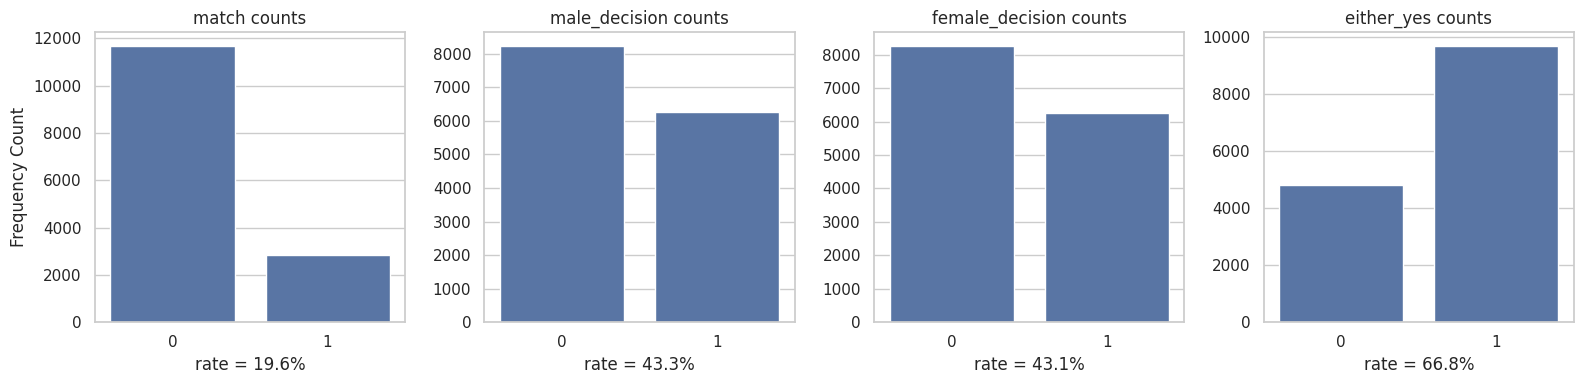

Decision pair distribution (male×female):
decision_pair
0×0    4814
0×1    3414
1×0    3439
1×1    2837

Participants: 1274 males, 1274 females, 120 events
Dates per male — median 12, min 6, max 15
Dates per female — median 12, min 6, max 15


In [5]:
# Outcome Distributions
f, ax = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for i, col in enumerate(["match", "male_decision", "female_decision", "either_yes"]):
    sns.countplot(x=col, data=df, ax=ax[i], order=[0, 1])
    ax[i].set_title(f"{col} counts")
    rate = df[col].mean()
    ax[i].set_xlabel(f"rate = {rate:.1%}")
ax[0].set_ylabel("Frequency Count")
for a in ax[1:]:
    a.set_ylabel("")
plt.tight_layout()
plt.show()

print("Decision pair distribution (male×female):")
print(df["decision_pair"].value_counts().sort_index().to_string())
print("\nParticipants: {} males, {} females, {} events".format(
    df["male_id"].nunique(), df["female_id"].nunique(), df["event_id"].nunique()
))
print("Dates per male — median {}, min {}, max {}".format(
    int(df.groupby("male_id").size().median()),
    df.groupby("male_id").size().min(),
    df.groupby("male_id").size().max(),
))
print("Dates per female — median {}, min {}, max {}".format(
    int(df.groupby("female_id").size().median()),
    df.groupby("female_id").size().min(),
    df.groupby("female_id").size().max(),
))

**Code Explanation:** <br>
Four simple countplots put the binary outcomes side by side. The x-axis label carries the empirical rate so the eye does not have to recompute percentages from bar heights.

**Interpretation:** <br>
Each side says yes roughly **43%** of the time, but mutual yes lands near **20%**. That gap is the heart of the problem: unilateral interest is common; reciprocity is harder. The four decision-pair cells (0×0, 0×1, 1×0, 1×1) make the asymmetry concrete — one-sided yeses dominate matches.

Dates-per-person medians near the mid-teens suggest a balanced rotation design inside events, not a long-tailed “super-dater” artifact.

***

### 3.2 Continuous ratings and preferences

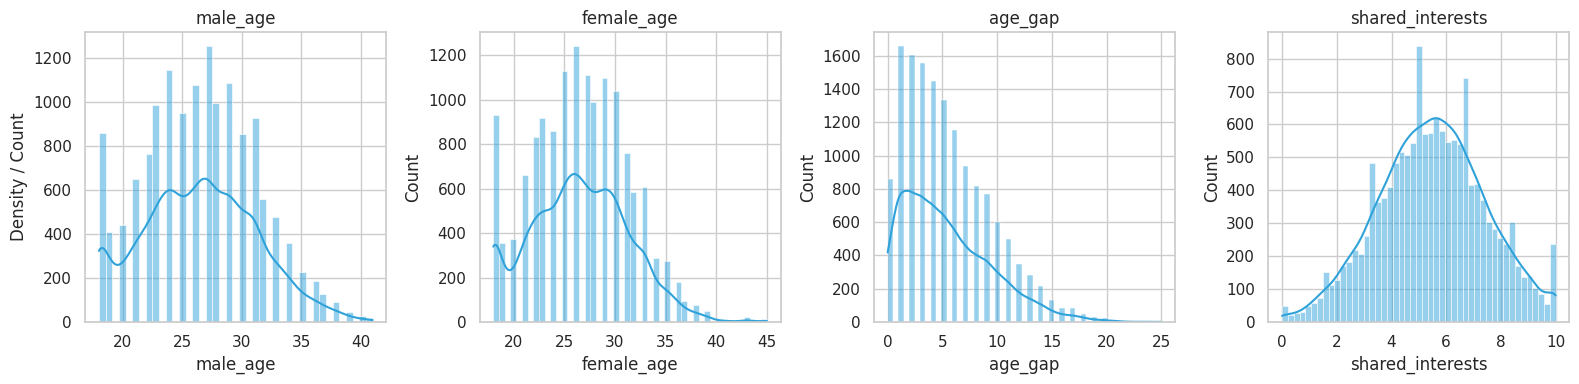

In [6]:
# Continuous Distributions — ages and interests
f, ax = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for i, col in enumerate(["male_age", "female_age", "age_gap", "shared_interests"]):
    sns.histplot(df[col], kde=True, ax=ax[i], color="#30a2da")
    ax[i].set_title(col)
ax[0].set_ylabel("Density / Count")
plt.tight_layout()
plt.show()

**Code Explanation:** <br>
Histograms with KDE overlays show shape, not just moments. Shared y-scales are *not* forced — age and interest live on different units.

**Distribution of Age:** <br>
My a priori expectation for a speed-dating sample would be a young, campus-heavy spike. Here both male and female ages peak in the mid-20s with a right tail into the 30s/40s. The two age distributions look nearly twins — good for paired comparison later.

**Distribution of Age Gap:** <br>
Absolute gaps pile up at small values and stretch out. Most pairs are close in age; a minority of large gaps will matter if match rates fall off in the tail.

**Distribution of Shared Interests:** <br>
Centered around the mid-scale (~5.5/10) with usable spread. This is a promising continuous lever for later stratification.

***

**Trait ratings: men rating women vs women rating men**

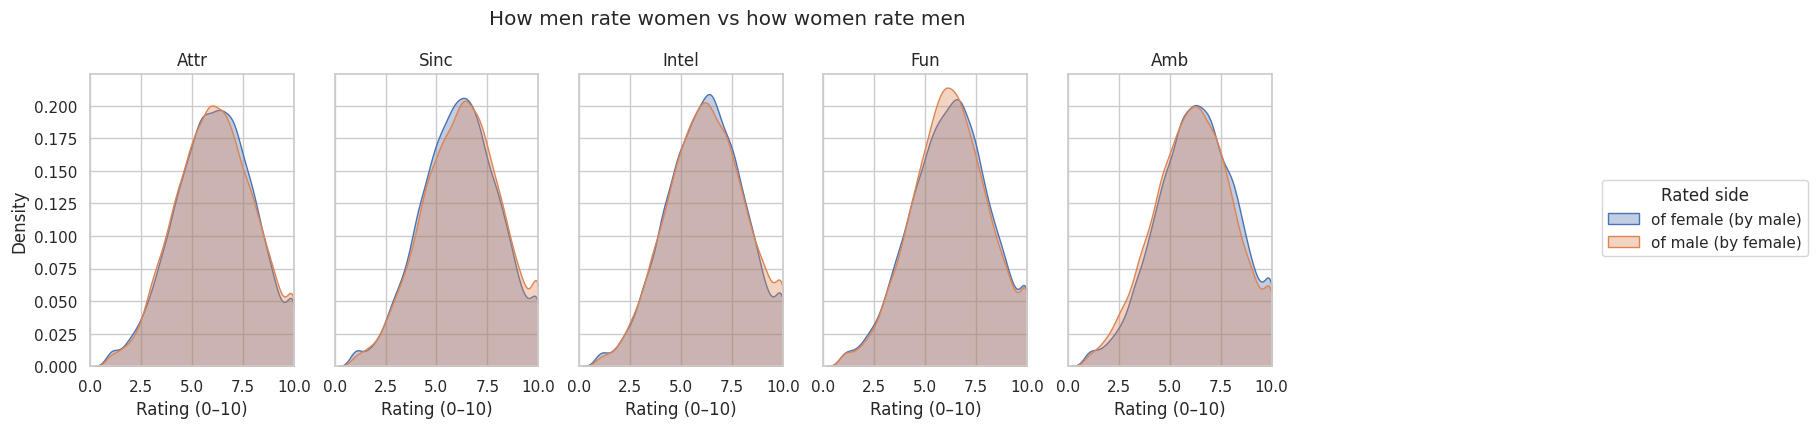

Mean trait ratings:


,of_female_by_male,of_male_by_female
attr,6.107,6.111
sinc,6.143,6.256
intel,6.192,6.242
fun,6.225,6.198
amb,6.302,6.164


In [7]:
f, axes = plt.subplots(1, 5, figsize=(17, 3.8), sharey=True)
for ax, t in zip(axes, TRAITS):
    sns.kdeplot(df[f"{t}_of_female"], ax=ax, fill=True, alpha=0.35, label="of female (by male)")
    sns.kdeplot(df[f"{t}_of_male"], ax=ax, fill=True, alpha=0.35, label="of male (by female)")
    ax.set_title(t.capitalize())
    ax.set_xlabel("Rating (0–10)")
    ax.set_xlim(0, 10)
axes[0].set_ylabel("Density")
handles, labels = axes[-1].get_legend_handles_labels()
f.legend(
    handles, labels,
    loc="center left", bbox_to_anchor=(1.01, 0.5),
    frameon=True, title="Rated side",
)
f.subplots_adjust(right=0.82)
f.suptitle("How men rate women vs how women rate men", y=1.05)
plt.show()

print("Mean trait ratings:")
means = pd.DataFrame({
    "of_female_by_male": [df[f"{t}_of_female"].mean() for t in TRAITS],
    "of_male_by_female": [df[f"{t}_of_male"].mean() for t in TRAITS],
}, index=TRAITS)
display(means.round(3))

**Interpretation:** <br>
The overlapping densities are striking: on average, men and women appear about equally “generous” (or stingy) across all five traits. Whatever gender story exists later is unlikely to be a crude mean-shift in how harshly people score partners. Differences, if any, will show up in *which* traits predict saying yes — not in who hands out higher scores overall.

***

### 3.3 Categorical social frequency

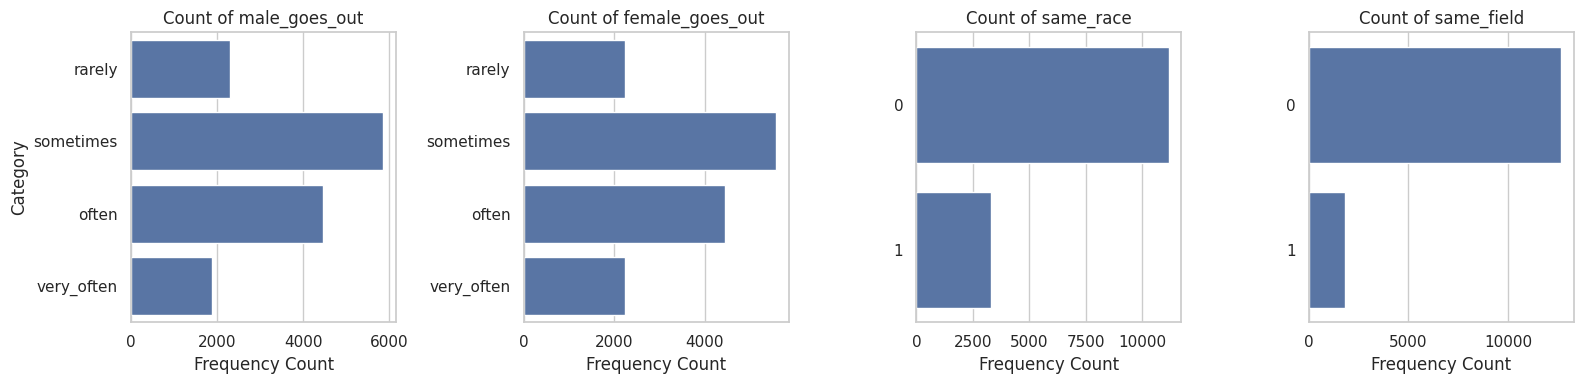

In [8]:
row_plots = ["male_goes_out", "female_goes_out", "same_race", "same_field"]
f, axes = plt.subplots(1, len(row_plots), figsize=(16, 4), sharex=False)

for i, x in enumerate(row_plots):
    order = list(GOES_OUT_ORDER) if "goes_out" in x else sorted(df[x].unique())
    sns.countplot(y=x, data=df, order=order, ax=axes[i])
    axes[i].set_title("Count of {}".format(x))
    axes[i].set_xlabel("Frequency Count")
axes[0].set_ylabel("Category")
for a in axes[1:]:
    a.set_ylabel("")
plt.tight_layout()
plt.show()

**Code Explanation:** <br>
Enumerating the loop lets each subplot share the same construction while keeping category order intentional (`GOES_OUT_ORDER` is ordinal).

**Interpretation:** <br>
`sometimes` and `often` dominate social-frequency answers — the tails (`rarely`, `very_often`) are smaller but large enough to compare match rates later. `same_race` and `same_field` are minority conditions (~23% and ~13%), so any homophily effect has to be large to show up as a raw count story; percentage-standardized plots will be fairer.

***

# **4. Multivariate Distribution:** <a id="Multivariate"></a>
### 4.1 Categorical Variable by Categorical Variable
In this section I use heatmaps of percentage pivot tables. Normalizing frequency into percentages — by table, by row, or by column — is the same technique that made the e-commerce clothing crosstabs readable when class sizes were uneven.

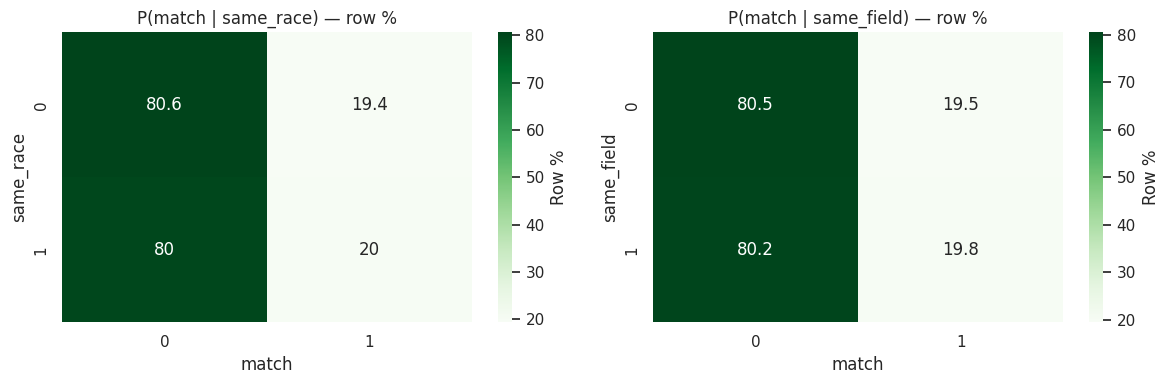

In [9]:
# Heatmaps of Percentage Pivot Table — demographic homophily vs match
f, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
sns.heatmap(
    pd.crosstab(df["same_race"], df["match"], normalize="index").mul(100).round(1),
    annot=True, fmt="g", cmap="Greens", ax=ax[0],
    cbar_kws={"label": "Row %"},
)
ax[0].set_title("P(match | same_race) — row %")

sns.heatmap(
    pd.crosstab(df["same_field"], df["match"], normalize="index").mul(100).round(1),
    annot=True, fmt="g", cmap="Greens", ax=ax[1],
    cbar_kws={"label": "Row %"},
)
ax[1].set_title("P(match | same_field) — row %")
plt.tight_layout()
plt.show()

**How to Interpret:** <br>
Row normalization answers: *among dates that share (or do not share) race/field, what fraction match?* That is the fair comparison when the “same” class is rare.

**Interpretation:** <br>
If demographic homophily were a major driver here, the `1` rows would light up with higher match percentages. They barely move. In *this* table, attraction and interests will have to carry the story — classic homophily findings from broader relationship science do not announce themselves in these two binary flags.

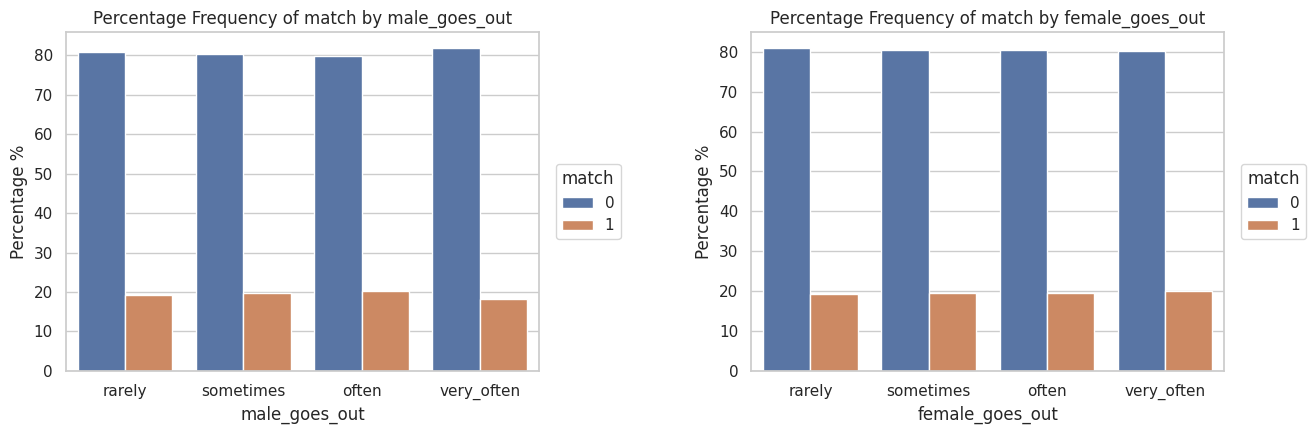

In [10]:
def percentstandardize_barplot(x, y, hue, data, ax=None, order=None):
    """
    Standardize by percentage the data using pandas functions, then plot using Seaborn.
    Function arguments are an extension of Seaborns'.
    """
    plot_df = (
        data[[x, hue]]
        .reset_index(drop=True)
        .groupby([x])[hue]
        .value_counts(normalize=True)
        .rename("Percentage")
        .mul(100)
        .reset_index()
        .sort_values(hue)
    )
    sns.barplot(x=x, y="Percentage", hue=hue, data=plot_df, ax=ax, order=order)
    if ax is None:
        plt.title("Percentage Frequency of {} by {}".format(hue, x))
        plt.ylabel("Percentage %")
    else:
        ax.set_title("Percentage Frequency of {} by {}".format(hue, x))
        ax.set_ylabel("Percentage %")


f, axes = plt.subplots(1, 2, figsize=(14, 4.5))
percentstandardize_barplot(
    "male_goes_out", "count", "match", df, ax=axes[0], order=GOES_OUT_ORDER
)
percentstandardize_barplot(
    "female_goes_out", "count", "match", df, ax=axes[1], order=GOES_OUT_ORDER
)
for ax in axes:
    sns.move_legend(ax, "center left", bbox_to_anchor=(1.02, 0.5), frameon=True, title="match")
plt.tight_layout()
f.subplots_adjust(right=0.88, wspace=0.45)
plt.show()

**Code Explanation:** <br>
`percentstandardize_barplot` converts raw counts into within-x percentages before plotting — the same helper pattern from the e-commerce notebook. Without it, the taller `sometimes` bars would dominate the eye even if match *rates* were identical.

**Interpretation:** <br>
Social frequency shifts match composition modestly. I would not bet a theory on goes-out alone; treat it as a secondary stratifier when we look at attraction next.

***

**Decision-pair structure (the four cells that define match):**

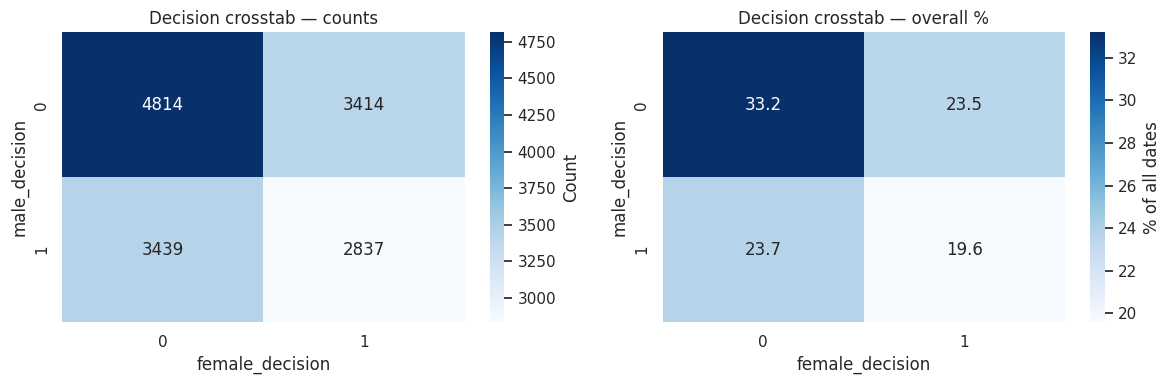

Match cell (1,1) share of all dates: 19.6%


In [11]:
f, ax = plt.subplots(1, 2, figsize=(12, 4))
ct_count = pd.crosstab(df["male_decision"], df["female_decision"])
ct_pct = pd.crosstab(df["male_decision"], df["female_decision"], normalize=True).mul(100).round(1)

sns.heatmap(ct_count, annot=True, fmt="g", cmap="Blues", ax=ax[0],
            cbar_kws={"label": "Count"})
ax[0].set_title("Decision crosstab — counts")

sns.heatmap(ct_pct, annot=True, fmt="g", cmap="Blues", ax=ax[1],
            cbar_kws={"label": "% of all dates"})
ax[1].set_title("Decision crosstab — overall %")
plt.tight_layout()
plt.show()

print("Match cell (1,1) share of all dates: {:.1%}".format(
    ((df["male_decision"] == 1) & (df["female_decision"] == 1)).mean()
))

**How to Interpret:** <br>
The bottom-right cell *is* `match`. The off-diagonals are one-sided interest. The top-left is mutual decline.

**Interpretation:** <br>
Most dates are mutual no or one-sided yes. Mutual yes is the rarest of the four substantive cells. Any feature that only boosts one person’s yes rate without helping reciprocity will look weaker against `match` than against that person’s own decision — a foreshadowing of why two-stage thinking (decide each side, then combine) is often more honest than predicting `match` as a monolithic label.

***

### 4.2 Continuous Variable by Categorical Variable

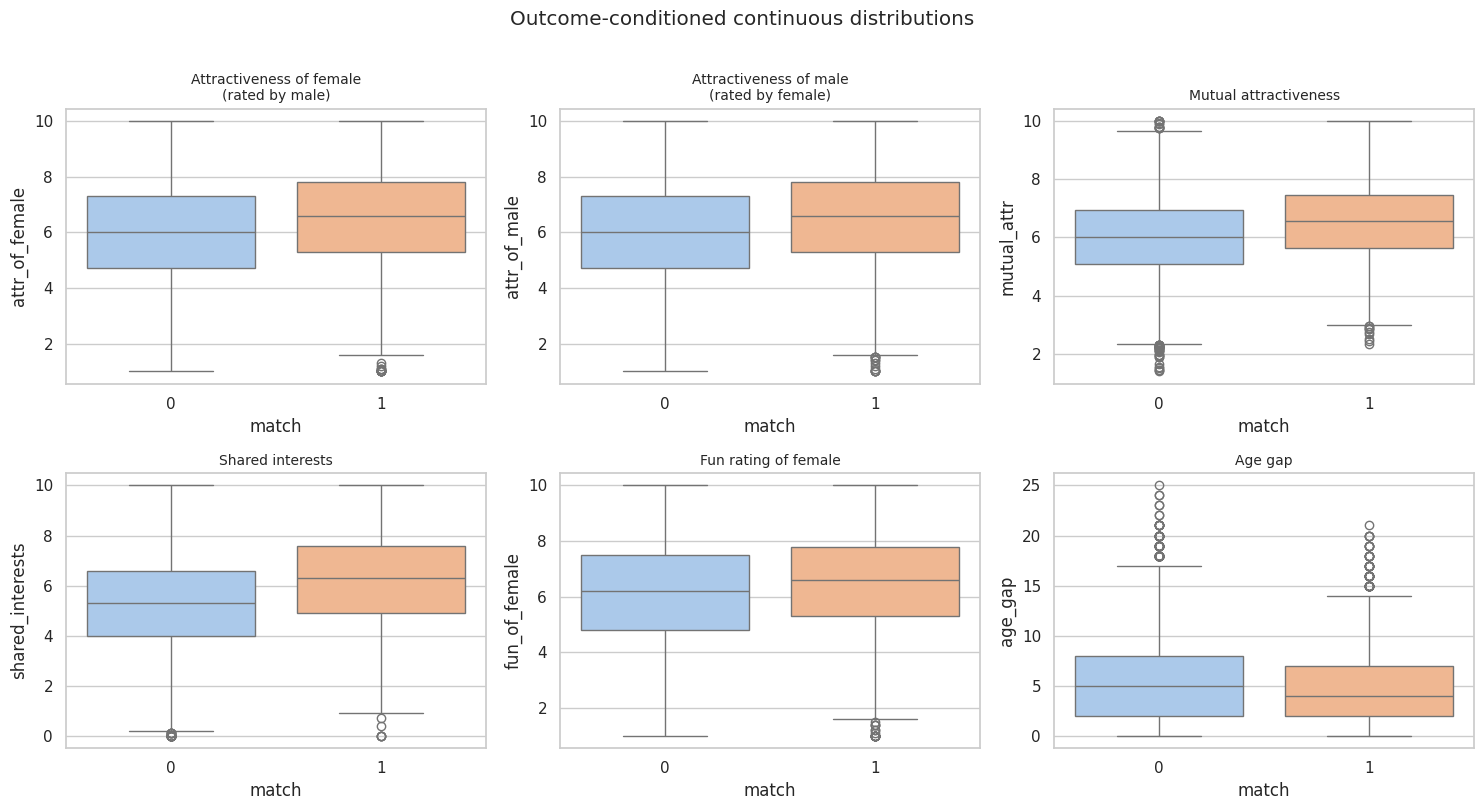

Mean difference (match=1 minus match=0):
  attr_of_female        Δ = +0.524
  attr_of_male          Δ = +0.543
  mutual_attr           Δ = +0.533
  shared_interests      Δ = +0.919
  fun_of_female         Δ = +0.335
  age_gap               Δ = -0.540


In [12]:
f, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_specs = [
    ("attr_of_female", "Attractiveness of female\n(rated by male)"),
    ("attr_of_male", "Attractiveness of male\n(rated by female)"),
    ("mutual_attr", "Mutual attractiveness"),
    ("shared_interests", "Shared interests"),
    ("fun_of_female", "Fun rating of female"),
    ("age_gap", "Age gap"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    sns.boxplot(data=df, x="match", y=col, ax=ax, palette="pastel")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("match")
plt.suptitle("Outcome-conditioned continuous distributions", y=1.01)
plt.tight_layout()
plt.show()

print("Mean difference (match=1 minus match=0):")
for col, _ in plot_specs:
    delta = df.loc[df["match"] == 1, col].mean() - df.loc[df["match"] == 0, col].mean()
    print(f"  {col:20s}  Δ = {delta:+.3f}")

**Interpretation:** <br>
Matched dates sit higher on attractiveness (especially mutual), fun, and shared interests. Age gap barely budges — another vote against demographics-as-destiny in this sample. The mutual attractiveness box separates more cleanly than either one-sided attractiveness box alone: reciprocity in *ratings* foreshadows reciprocity in *decisions*.

***

**Shared interests bins — a monotonic check:**

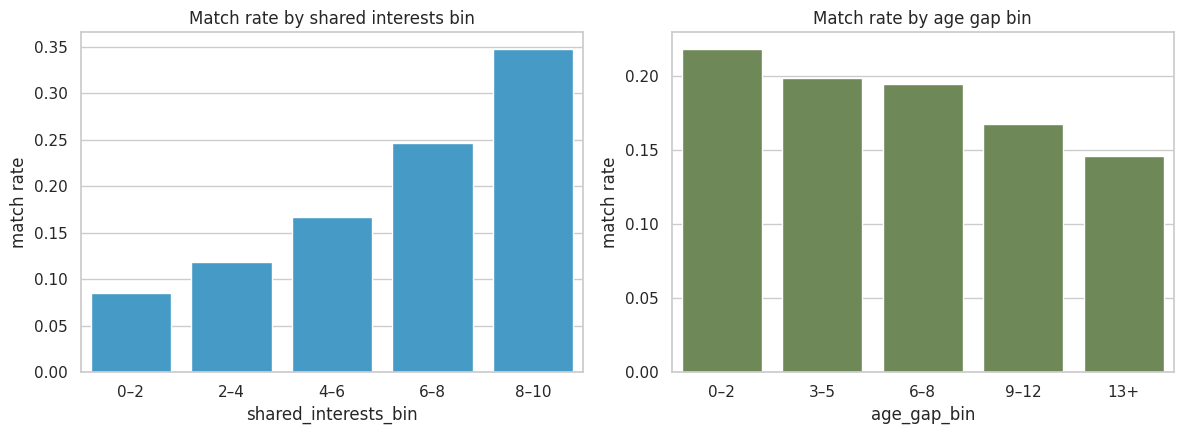

,shared_interests_bin,n,match_rate,match_rate_pct
0,0–2,622,0.085209,8.52
1,2–4,2749,0.118952,11.90
2,4–6,5506,0.167090,16.71
3,6–8,4160,0.246635,24.66
4,8–10,1467,0.348330,34.83


,age_gap_bin,n,match_rate,match_rate_pct
0,0–2,4122,0.218826,21.88
1,3–5,4335,0.198847,19.88
2,6–8,2907,0.194702,19.47
3,9–12,2221,0.167942,16.79
4,13+,919,0.145811,14.58


In [13]:
df["shared_interests_bin"] = pd.cut(
    df["shared_interests"],
    bins=[0, 2, 4, 6, 8, 10],
    include_lowest=True,
    labels=["0–2", "2–4", "4–6", "6–8", "8–10"],
)
df["age_gap_bin"] = pd.cut(
    df["age_gap"],
    bins=[-0.1, 2, 5, 8, 12, 30],
    labels=["0–2", "3–5", "6–8", "9–12", "13+"],
)

si = (
    df.groupby("shared_interests_bin", observed=True)["match"]
    .agg(n="count", match_rate="mean")
    .reset_index()
)
ag = (
    df.groupby("age_gap_bin", observed=True)["match"]
    .agg(n="count", match_rate="mean")
    .reset_index()
)

f, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=si, x="shared_interests_bin", y="match_rate", color="#30a2da", ax=axes[0])
axes[0].set_title("Match rate by shared interests bin")
axes[0].set_ylabel("match rate")
sns.barplot(data=ag, x="age_gap_bin", y="match_rate", color="#6d904f", ax=axes[1])
axes[1].set_title("Match rate by age gap bin")
axes[1].set_ylabel("match rate")
plt.tight_layout()
plt.show()

display(si.assign(match_rate_pct=lambda d: (100 * d["match_rate"]).round(2)))
display(ag.assign(match_rate_pct=lambda d: (100 * d["match_rate"]).round(2)))

**Interpretation:** <br>
Shared interests show a clean, fairly monotonic climb in match rate — moving from the bottom bin toward the top is one of the clearest non-leakage stories in the notebook. Age-gap bins are flatter; if there is a penalty for large gaps, it is mild next to the interest gradient.

***

### 4.3 Continuous Variables on Continuous Variables

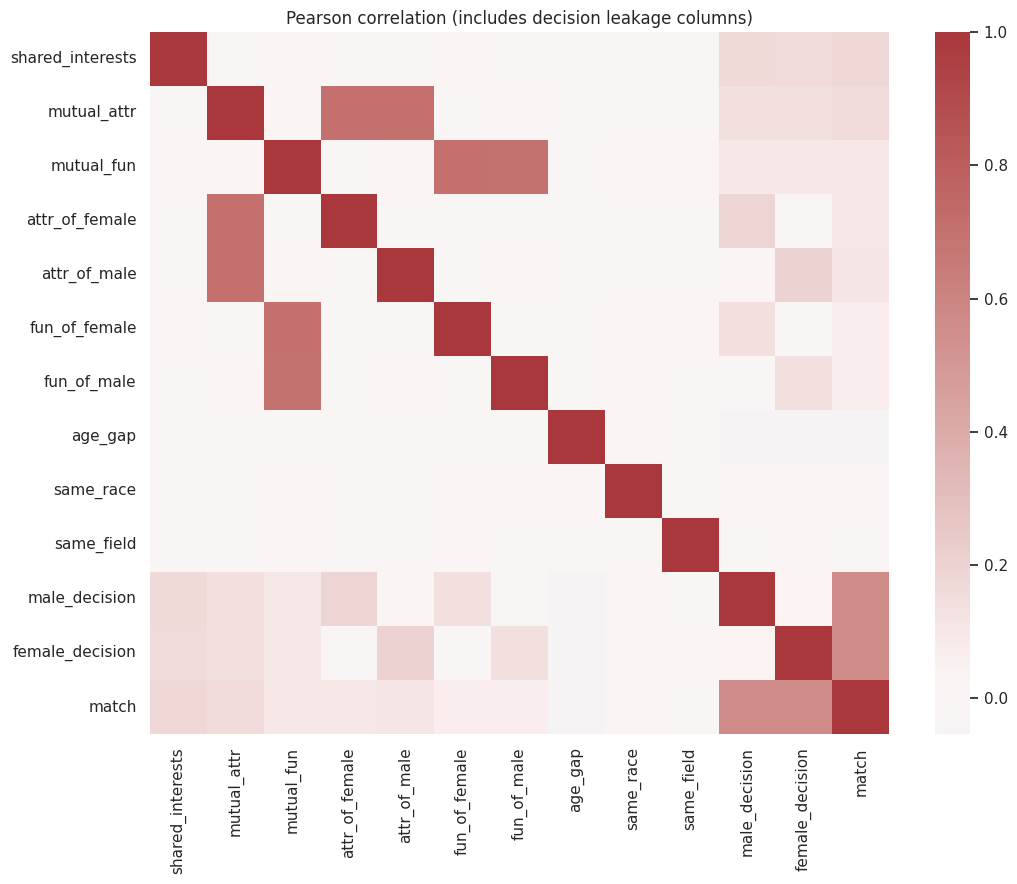

Pearson r with match (sorted by |r|):
female_decision     0.567
male_decision       0.565
shared_interests    0.185
mutual_attr         0.157
attr_of_male        0.113
attr_of_female      0.109
mutual_fun          0.101
fun_of_male         0.073
fun_of_female       0.070
age_gap            -0.053
same_race           0.007
same_field          0.003


In [14]:
# Correlation board — honest features + leakage columns for contrast
corr_cols = [
    "shared_interests", "mutual_attr", "mutual_fun",
    "attr_of_female", "attr_of_male", "fun_of_female", "fun_of_male",
    "age_gap", "same_race", "same_field",
    "male_decision", "female_decision", "match",
]
cm = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=False, cmap="vlag", center=0)
plt.title("Pearson correlation (includes decision leakage columns)")
plt.tight_layout()
plt.show()

print("Pearson r with match (sorted by |r|):")
print(cm["match"].drop("match").sort_values(key=np.abs, ascending=False).round(3).to_string())

**How to Interpret:** <br>
Read the `match` column (or row) first. The decision columns will dominate — that is the leakage trap announcing itself visually. Among the remaining features, look for which rating and interest variables still clear a meaningful threshold.

**Interpretation:** <br>
`male_decision` and `female_decision` correlate with `match` around **r ≈ 0.56–0.57**, far above everything else, because they *define* the target. Among honest signals, attractiveness, fun, mutual scores, and shared interests lead; `same_race`, `same_field`, and `age_gap` barely register. The five trait ratings also co-move within each side (a “halo” — people rated attractive also tend to get higher sincerity/fun scores), so single-trait correlations partly share variance.

***

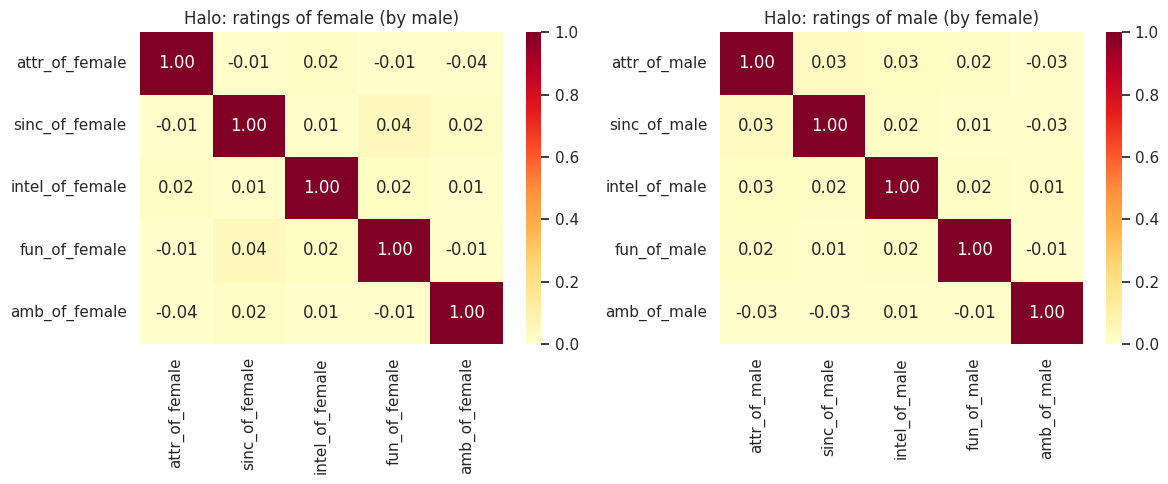

In [15]:
# Halo effect within each side's rating vector
female_ratings = df[[f"{t}_of_female" for t in TRAITS]].corr()
male_ratings = df[[f"{t}_of_male" for t in TRAITS]].corr()

f, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(female_ratings, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Halo: ratings of female (by male)")
sns.heatmap(male_ratings, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Halo: ratings of male (by female)")
plt.tight_layout()
plt.show()

**Interpretation:** <br>
Warm off-diagonals confirm the halo. Attractiveness is not an isolated dial; it travels with fun and the other traits. When we later say “attraction predicts match,” we should remember we are also picking up correlated warmth on sincerity/intelligence/ambition unless we partial those out.

***

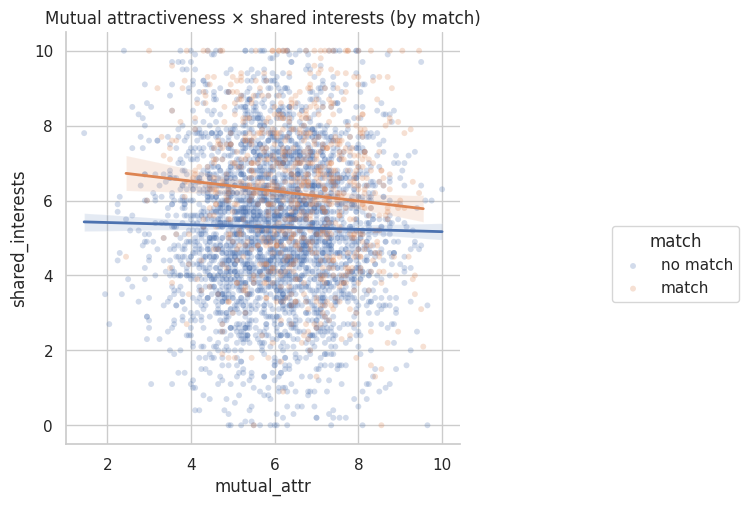

corr(mutual_attr, shared_interests) overall = -0.002 (p=8.42e-01)


In [16]:
sample = df.sample(min(4000, len(df)), random_state=0).copy()
sample["match_label"] = sample["match"].map({0: "no match", 1: "match"})

g = sns.lmplot(
    data=sample,
    x="mutual_attr",
    y="shared_interests",
    hue="match_label",
    scatter_kws={"alpha": 0.25, "s": 18, "edgecolor": "none"},
    line_kws={"lw": 2},
    height=5,
    aspect=1.2,
    legend=False,
)
g.ax.set_title("Mutual attractiveness × shared interests (by match)")
handles, labels = g.ax.get_legend_handles_labels()
g.fig.legend(
    handles, labels,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, title="match",
)
g.fig.subplots_adjust(right=0.78)
plt.show()

r_m, p_m = stats.pearsonr(df["mutual_attr"], df["shared_interests"])
print(f"corr(mutual_attr, shared_interests) overall = {r_m:.3f} (p={p_m:.2e})")

**Interpretation:** <br>
Matches concentrate toward the upper-right — higher mutual attraction *and* higher shared interests. The two levers are positively related but not redundant; each still has room to explain match beyond the other. This scatter is the visual intuition behind engineered fit features in the next sections.

***

# **5. The Leakage Trap:** <a id="Leakage"></a>
This section is not a modeling flex — it is a sanity check that should feel almost too obvious once stated.

match == (male_decision AND female_decision) for 100.0000% of rows
'Model-free' accuracy using just this identity: 100.0000%


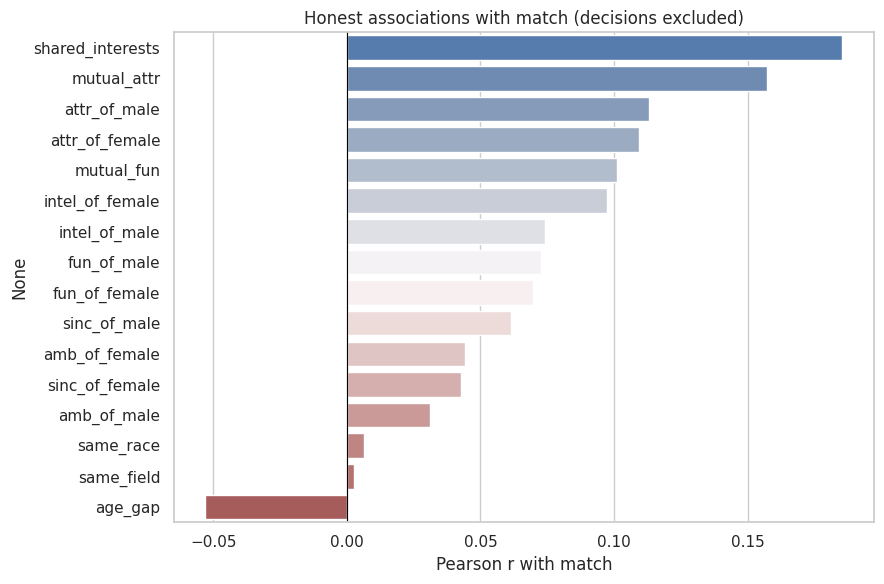

shared_interests    0.185
mutual_attr         0.157
attr_of_male        0.113
attr_of_female      0.109
mutual_fun          0.101
intel_of_female     0.097
intel_of_male       0.074
fun_of_male         0.073
fun_of_female       0.070
sinc_of_male        0.061
amb_of_female       0.044
sinc_of_female      0.043
amb_of_male         0.031
same_race           0.007
same_field          0.003
age_gap            -0.053


In [17]:
identity_check = (df["match"] == (df["male_decision"] & df["female_decision"])).mean()
naive_prediction = (df["male_decision"] & df["female_decision"]).astype(int)
accuracy = (naive_prediction == df["match"]).mean()

print(f"match == (male_decision AND female_decision) for {identity_check:.4%} of rows")
print(f"'Model-free' accuracy using just this identity: {accuracy:.4%}")

# Contrast: correlations if we *exclude* decisions
honest = [
    "shared_interests", "mutual_attr", "mutual_fun",
    "attr_of_female", "attr_of_male", "fun_of_female", "fun_of_male",
    "sinc_of_female", "sinc_of_male", "intel_of_female", "intel_of_male",
    "amb_of_female", "amb_of_male", "age_gap", "same_race", "same_field",
]
honest_corr = df[honest + ["match"]].corr()["match"].drop("match").sort_values(ascending=False)

f, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=honest_corr.values, y=honest_corr.index, hue=honest_corr.index,
            palette="vlag", legend=False, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with match")
ax.set_title("Honest associations with match (decisions excluded)")
plt.tight_layout()
plt.show()

print(honest_corr.round(3).to_string())

**Code Explanation:** <br>
The identity check prints the tautology. The bar chart then shows the *interesting* problem: what still correlates with match when decisions are forbidden as features.

**Interpretation:** <br>
This is not a modeling result — it is a definition. A notebook that “predicts” match from `male_decision` / `female_decision` can hit 100% accuracy without learning anything about attraction. The honest board is humbler: mutual attraction and shared interests lead; demographics trail. That humility is the point.

***

# **6. Self-Perception and Stated Preferences:** <a id="Preferences"></a>

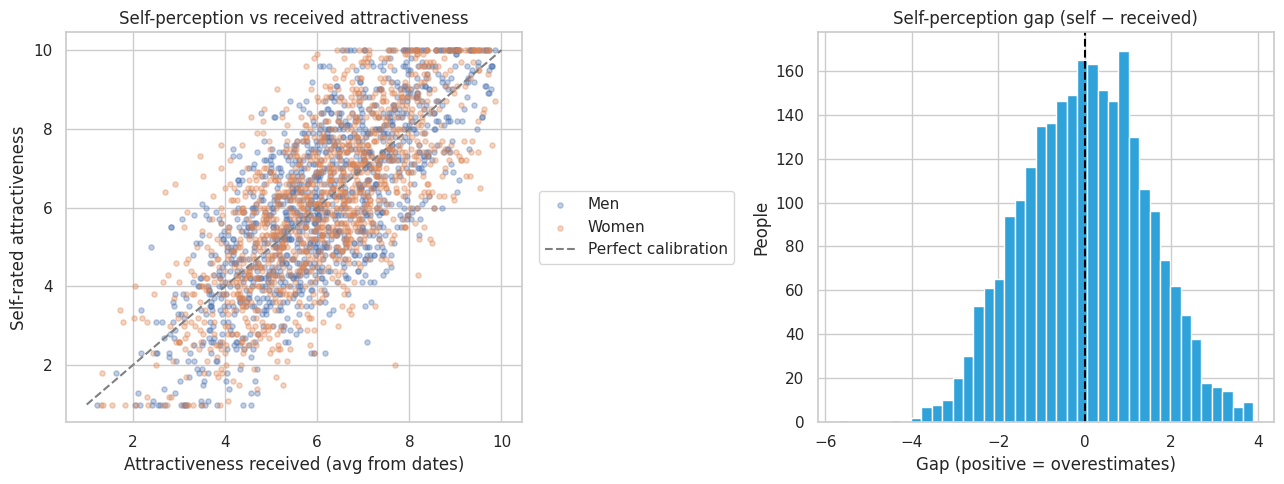

Overestimate (gap > 0.5):   37.4%
Underestimate (gap < -0.5): 36.6%
Within ±0.5:               25.9%
Mean gap (population):     +0.003


In [18]:
# Per-person calibration gap: self rating vs average rating received from dates
male_perceived = df.groupby("male_id")["attr_of_male"].mean()
male_self = df.groupby("male_id")["male_self_attr"].first()
male_gap = (male_self - male_perceived).rename("gap")

female_perceived = df.groupby("female_id")["attr_of_female"].mean()
female_self = df.groupby("female_id")["female_self_attr"].first()
female_gap = (female_self - female_perceived).rename("gap")

f, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(male_perceived, male_self, s=14, alpha=0.35, label="Men")
axes[0].scatter(female_perceived, female_self, s=14, alpha=0.35, label="Women")
lims = [1, 10]
axes[0].plot(lims, lims, ls="--", color="gray", lw=1.5, label="Perfect calibration")
axes[0].set_xlabel("Attractiveness received (avg from dates)")
axes[0].set_ylabel("Self-rated attractiveness")
axes[0].set_title("Self-perception vs received attractiveness")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

both_gap = pd.concat([male_gap, female_gap])
axes[1].hist(both_gap, bins=40, color="#30a2da", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1.5)
axes[1].set_title("Self-perception gap (self − received)")
axes[1].set_xlabel("Gap (positive = overestimates)")
axes[1].set_ylabel("People")
plt.tight_layout()
plt.show()

overest = (both_gap > 0.5).mean()
underest = (both_gap < -0.5).mean()
calibrated = 1 - overest - underest
print(f"Overestimate (gap > 0.5):   {overest:.1%}")
print(f"Underestimate (gap < -0.5): {underest:.1%}")
print(f"Within ±0.5:               {calibrated:.1%}")
print(f"Mean gap (population):     {both_gap.mean():+.3f}")

**Interpretation:** <br>
At the *population* level, self-rated attractiveness and received attractiveness look roughly centered — the mean gap hugs zero. At the *individual* level, miscalibration is common: sizable shares overestimate and underestimate by more than half a point, and those errors cancel. Averages hide the personal comedy (and tragedy) of self-image.

***

**Stated importance of looks vs revealed looks → yes link:**

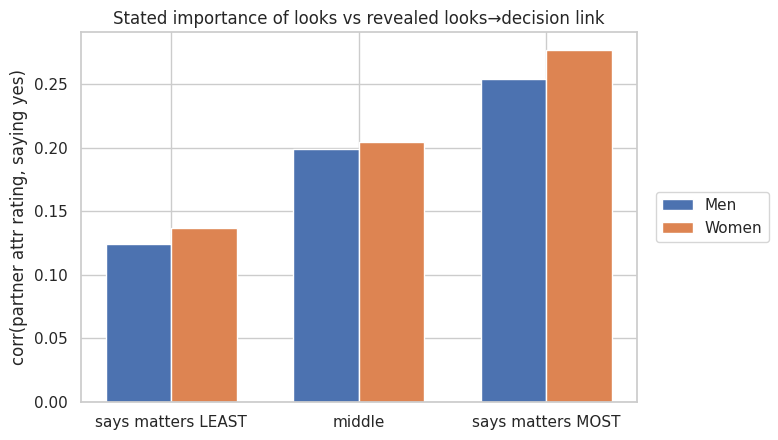

Men   corr by stated-preference tier: {'says matters LEAST': 0.124, 'middle': 0.199, 'says matters MOST': 0.254}
Women corr by stated-preference tier: {'says matters LEAST': 0.137, 'middle': 0.205, 'says matters MOST': 0.277}


In [19]:
tmp = df.copy()
tmp["male_pref_attr_tier"] = pd.qcut(
    tmp["male_pref_attr"], 3,
    labels=["says matters LEAST", "middle", "says matters MOST"],
)
tmp["female_pref_attr_tier"] = pd.qcut(
    tmp["female_pref_attr"], 3,
    labels=["says matters LEAST", "middle", "says matters MOST"],
)

male_corrs = tmp.groupby("male_pref_attr_tier", observed=True).apply(
    lambda g: g["attr_of_female"].corr(g["male_decision"]), include_groups=False
)
female_corrs = tmp.groupby("female_pref_attr_tier", observed=True).apply(
    lambda g: g["attr_of_male"].corr(g["female_decision"]), include_groups=False
)

f, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, male_corrs.values, width, label="Men")
ax.bar(x + width / 2, female_corrs.values, width, label="Women")
ax.set_xticks(x)
ax.set_xticklabels(male_corrs.index)
ax.set_ylabel("corr(partner attr rating, saying yes)")
ax.set_title("Stated importance of looks vs revealed looks→decision link")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
f.subplots_adjust(right=0.78)
plt.show()

print("Men   corr by stated-preference tier:", {k: round(v, 3) for k, v in male_corrs.items()})
print("Women corr by stated-preference tier:", {k: round(v, 3) for k, v in female_corrs.items()})

**Interpretation:** <br>
There *is* a real, directionally consistent relationship — people who claim attractiveness matters more do show a stronger looks→yes correlation. But the tier-to-tier lift is modest next to how dramatically survey preference points vary. Stated preferences are not theater, yet they overpromise relative to revealed behavior. That gap is itself a finding.

***

# **7. Fit Features and Multivariate Association:** <a id="Fit"></a>

Engineered / core feature correlations with match:
shared_interests             0.185
mutual_attr                  0.157
attr_of_male                 0.113
attr_of_female               0.109
mutual_fun                   0.101
pref_weighted_attr_female    0.083
pref_weighted_attr_male      0.079
rating_spread_of_male       -0.010
rating_spread_of_female     -0.024

Match rate by mutual_attr quintile:


,count,mean
mutual_attr,,
Q1,2971,0.117
Q2,2873,0.152
Q3,2928,0.192
Q4,2833,0.225
Q5,2899,0.294


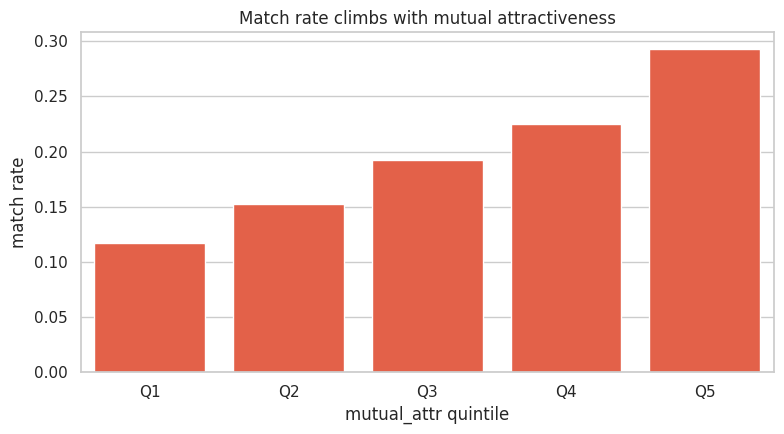

In [20]:
df["pref_weighted_attr_male"] = (df["male_pref_attr"] / 100) * df["attr_of_female"]
df["pref_weighted_attr_female"] = (df["female_pref_attr"] / 100) * df["attr_of_male"]
df["rating_spread_of_female"] = df[[f"{t}_of_female" for t in TRAITS]].std(axis=1)
df["rating_spread_of_male"] = df[[f"{t}_of_male" for t in TRAITS]].std(axis=1)

eng_cols = [
    "mutual_attr", "mutual_fun",
    "pref_weighted_attr_male", "pref_weighted_attr_female",
    "rating_spread_of_female", "rating_spread_of_male",
    "shared_interests", "attr_of_female", "attr_of_male",
]
eng_corr = (
    df[eng_cols + ["match"]].corr(method="pearson")["match"]
    .drop("match")
    .sort_values(ascending=False)
)
print("Engineered / core feature correlations with match:")
print(eng_corr.round(3).to_string())

bins = pd.qcut(df["mutual_attr"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
qtab = df.groupby(bins, observed=True)["match"].agg(["count", "mean"])
print("\nMatch rate by mutual_attr quintile:")
display(qtab.round(3))

f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=qtab.index.astype(str), y=qtab["mean"], color="#fc4f30", ax=ax)
ax.set_ylabel("match rate")
ax.set_xlabel("mutual_attr quintile")
ax.set_title("Match rate climbs with mutual attractiveness")
plt.tight_layout()
plt.show()

**Code Explanation:** <br>
`mutual_attr` averages the two attractiveness ratings. Preference-weighted versions multiply stated importance by the partner’s attractiveness. Rating *spread* asks whether uneven trait profiles (spiky scorecards) relate to match differently than flat ones.

**Interpretation:** <br>
`mutual_attr` is a noticeably stronger single associate than either one-sided attractiveness score. Quintiles make the gradient operational: moving from the bottom fifth of mutual attraction to the top fifth roughly doubles (or more) the chance of a mutual yes. Preference weighting helps a little; rating spread is a weaker story than level effects.

***

**Event-level view — do “hotter” events match more?**

Events: 120 | corr(mean mutual_attr, match_rate) = 0.396 (p=7.75e-06)


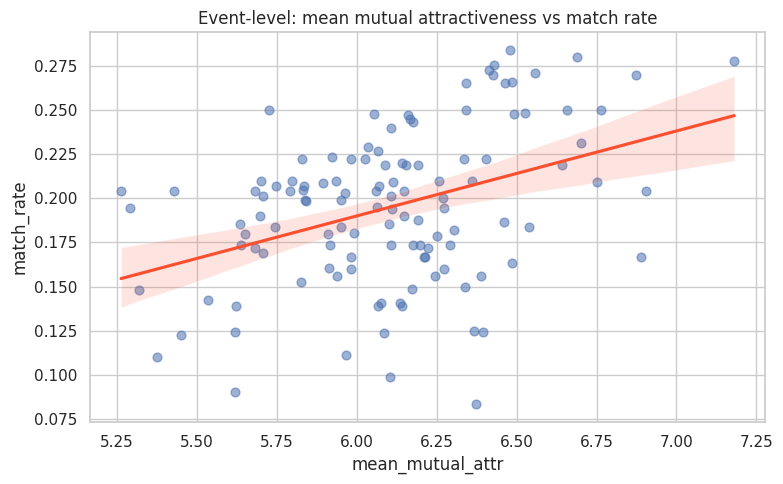

,count,mean,std,min,25%,50%,75%,max
event_id,120.0,59.500000,34.785054,0.000000,29.750000,59.500000,89.250000,119.000000
n,120.0,120.866667,60.388787,36.000000,64.000000,121.000000,169.000000,225.000000
match_rate,120.0,0.195067,0.043736,0.083333,0.166667,0.198980,0.222222,0.283951
mean_mutual_attr,120.0,6.105549,0.359428,5.263265,5.882164,6.107359,6.339334,7.180556
mean_shared,120.0,5.474542,0.185373,4.900000,5.361417,5.474222,5.600617,5.953061


In [21]:
event_summary = (
    df.groupby("event_id", observed=True)
    .agg(
        n=("match", "size"),
        match_rate=("match", "mean"),
        mean_mutual_attr=("mutual_attr", "mean"),
        mean_shared=("shared_interests", "mean"),
    )
    .reset_index()
)
r_event, p_event = stats.pearsonr(event_summary["mean_mutual_attr"], event_summary["match_rate"])
print(f"Events: {len(event_summary)} | corr(mean mutual_attr, match_rate) = {r_event:.3f} (p={p_event:.2e})")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=event_summary,
    x="mean_mutual_attr",
    y="match_rate",
    scatter_kws={"alpha": 0.55, "s": 40},
    line_kws={"color": "#fc4f30"},
)
plt.title("Event-level: mean mutual attractiveness vs match rate")
plt.tight_layout()
plt.show()

display(event_summary.describe().T)

**Interpretation:** <br>
Even after collapsing to 120 events, mean mutual attractiveness still tracks event match rate. That suggests the attraction story is not only within-date noise — rooms (or nights) with higher average rated chemistry also produce more mutual yeses. Still associational: events differ in composition, not just “magic.”

***

**Leakage-free RandomForest importances (associational, not a leaderboard model):**

Top RandomForest feature importances (predicting match; decisions excluded):
shared_interests             0.077246
mutual_attr                  0.049659
intel_of_female              0.047118
mutual_fun                   0.043375
intel_of_male                0.042141
attr_of_male                 0.041575
attr_of_female               0.040703
pref_weighted_attr_female    0.040441
sinc_of_male                 0.040101
pref_weighted_attr_male      0.039818
sinc_of_female               0.039780
amb_of_female                0.039731
fun_of_male                  0.038582
amb_of_male                  0.037895
female_pref_intel            0.037527
male_pref_intel              0.036895
fun_of_female                0.036831
female_pref_attr             0.036770


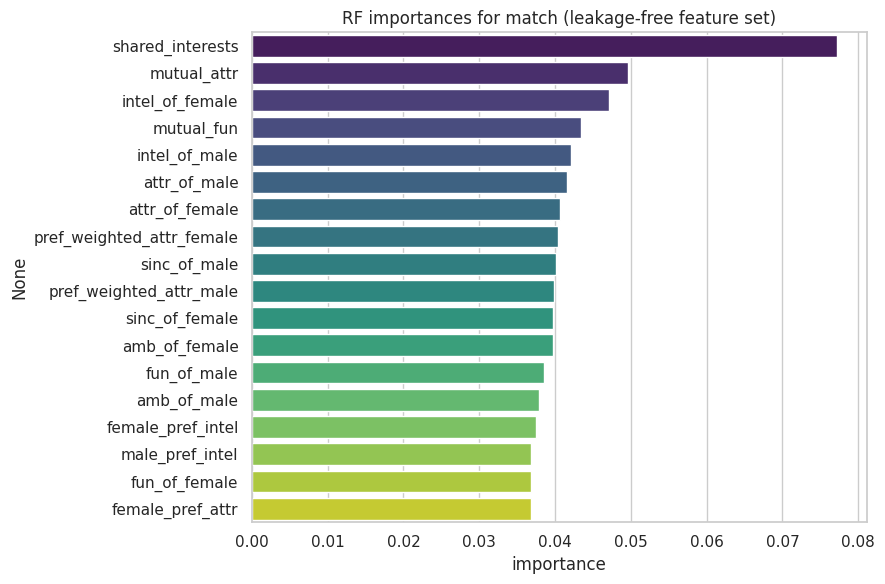

In [22]:
feat_cat = ["male_goes_out", "female_goes_out"]
feat_num = [
    "male_age", "female_age", "age_gap", "same_race", "same_field", "shared_interests",
    "attr_of_female", "sinc_of_female", "intel_of_female", "fun_of_female", "amb_of_female",
    "attr_of_male", "sinc_of_male", "intel_of_male", "fun_of_male", "amb_of_male",
    "male_pref_attr", "male_pref_intel", "female_pref_attr", "female_pref_intel",
    "male_self_attr", "female_self_attr",
    "mutual_attr", "mutual_fun",
    "pref_weighted_attr_male", "pref_weighted_attr_female",
]
assert "male_decision" not in feat_num + feat_cat
assert "female_decision" not in feat_num + feat_cat

X = df[feat_cat + feat_num]
y = df["match"]
pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat),
        ("num", "passthrough", feat_num),
    ])),
    ("model", RandomForestClassifier(
        n_estimators=200, random_state=0, n_jobs=-1, class_weight="balanced"
    )),
])
pipe.fit(X, y)
enc = pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = list(enc.get_feature_names_out(feat_cat))
imp = pipe.named_steps["model"].feature_importances_
imp_s = pd.Series(imp, index=cat_names + feat_num).sort_values(ascending=False).head(18)

print("Top RandomForest feature importances (predicting match; decisions excluded):")
print(imp_s.to_string())

f, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp_s.values, y=imp_s.index, hue=imp_s.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("importance")
ax.set_title("RF importances for match (leakage-free feature set)")
plt.tight_layout()
plt.show()

**How to Interpret:** <br>
These importances are fit on the *full* table for exploration — they are a nonlinear companion to the correlation board, not cross-validated predictive performance. Decision columns are deliberately absent.

**Interpretation:** <br>
Shared interests and mutual / partner rating features rise to the top; demographic flags and goes-out dummies do not. That aligns with the simpler plots: the levers that move match probability in this micro-lab are chemistry and common ground, not checkbox similarity.

***

# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A clean micro-laboratory of 14,504 short dates. Mutual match is uncommon (~20%) even though unilateral interest is common (~43% yes per side).

**What actually moves with match:** <br>
- Mutual attractiveness and fun, partner attractiveness, and shared interests.
- Demographic homophily (`same_race`, `same_field`) and age gap are near-noise here.
- Halo effects mean trait ratings travel together — do not over-interpret one trait in isolation.

**What will fool you:** <br>
`match` is exactly `male_decision ∧ female_decision`. Including those columns as features is a tautology, not insight.

**What people say vs what they do:** <br>
Self-perception errors cancel in the aggregate but are large person-to-person. Stated preference for looks tracks a modestly stronger revealed looks→yes link — real, but smaller than the survey drama suggests.

**Natural next questions to explore in follow-up cells:** <br>
1. Predict `male_decision` and `female_decision` separately, then multiply probabilities — does calibration improve vs predicting `match` directly?
2. Person-level yes-rates (computed carefully out-of-fold) as popularity features.
3. Within-event rankings: is being the most attractive person *in the room* different from absolute attractiveness?
4. Interaction slices: high shared interests *and* low mutual attr — which wins?
5. Event fixed effects: how much match variation is between nights vs within nights?

Use the patterns above as associations and prompts for the next plot — not as advice about love.

***